In [ ]:
!pip3 install tensorflow

In [ ]:
# mnist 데이터를 이용하여 숫자 판별하기
from tensorflow.keras.datasets.mnist import load_data
(x_train,y_train),(x_test,y_test)=load_data(path='mnist.npz')
print(x_train.shape,y_train.shape) #60000건
print(x_test.shape,y_test.shape)   #10000건

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [5]:
#임의로 3개의 이미지 출력하기
import matplotlib.pyplot as plt
import numpy as np

random_idx = np.random.randint(60000,size=3)
random_idx

array([56182, 25664, 26689])

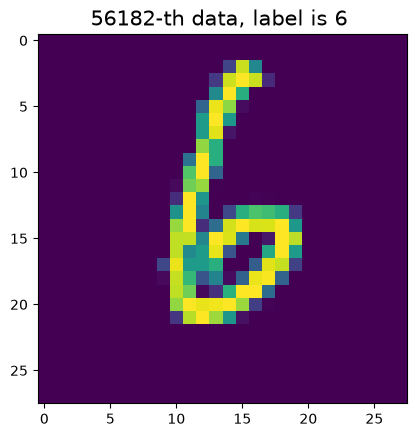

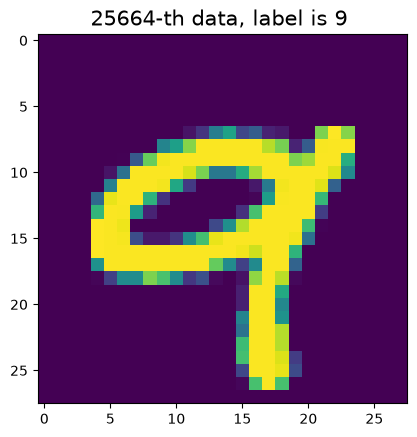

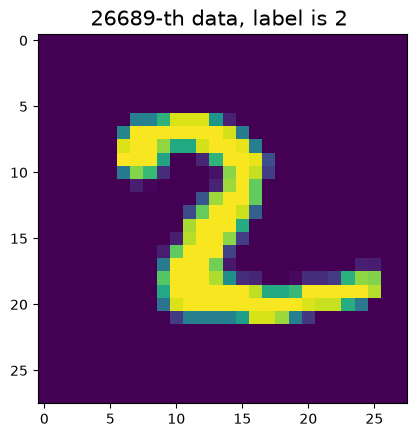

In [ ]:
for idx in random_idx :
    img = x_train[idx, :]
    label = y_train[idx]
    plt.figure()
    plt.imshow(img) # 이미지 출력
    plt.title('%d-th data, label is %d ' % (idx,label), fontsize=15 )

In [ ]:
print(x_train[random_idx[0],:]) #mnist 데이터 28*28 인 흑백 이미지  0:검정, 255:흰색

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  53 234 119   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  42 235 254 234  31
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 122 254 159   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  83 247 211   7   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 140 254 135   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 140 243  14   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 213 159   0   

In [8]:
#검증 데이터 생성 : 학습 도중에 검증(valid 데이터)
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.3,random_state=77)
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)


In [ ]:
#데이터 전처리하기
'''
 정규화
   MinMax normalization : X = (x - min) / (max - min)
   Robust normalization : X = (x - 중간값) / (3분위값 - 1분위값)
   Standardization : X = x - mean / std 
'''
x_train = (x_train.reshape((42000, 28 * 28)))  / 255   #MinMax 정규화.
x_val = (x_val.reshape((18000, 28 * 28))) / 255
x_test = (x_test.reshape((10000, 28 * 28))) / 255

In [ ]:
#레이블 전처리
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)  #원핫인코딩 => 값의 위치만 1로, 나머지는 0으로 변경
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

In [11]:
y_train[:3]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(64, activation='relu',input_shape=(784,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(optimizer='adam',  #옵티마이저 함수 : Adam
              loss= 'categorical_crossentropy',  #손실함수, 다중분류에서 사용되는 함수
              metrics=['acc'])   #평가지표 : 정확도

'''
        가중치의 갯수
  1층 : (784 + 1) * 64 = 50240
  2층 : (64 + 1 ) * 32 = 2080
  3층 : (32 + 1 ) * 10 = 330 

  전체 가중치 갯수 : 50240 + 2080 + 330 = 52650
'''

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
''' 
x_train,y_train : 학습데이터
epochs=30 : 학습 횟수
validation_data = (x_val,y_val) : 검증데이터. 학습하지 않고, 테스트
batch_size = 128 : 학습하는 데이터의 갯수
                   4200 / 128 = 329번
'''
history = model.fit(x_train,y_train,epochs=30,
                    batch_size = 128,
                    validation_data = (x_val,y_val))

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - acc: 0.8583 - loss: 0.5037 - val_acc: 0.9277 - val_loss: 0.2475
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - acc: 0.9411 - loss: 0.2054 - val_acc: 0.9440 - val_loss: 0.1875
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - acc: 0.9556 - loss: 0.1520 - val_acc: 0.9519 - val_loss: 0.1616
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - acc: 0.9648 - loss: 0.1229 - val_acc: 0.9561 - val_loss: 0.1437
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - acc: 0.9703 - loss: 0.1030 - val_acc: 0.9594 - val_loss: 0.1324
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - acc: 0.9743 - loss: 0.0878 - val_acc: 0.9647 - val_loss: 0.1232
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - acc: 0.9778 - loss: 0.0758 - val_acc: 0.9636 - val_loss: 0.1199
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - acc: 0.9810 - loss: 0.0658 - val_acc: 0.9651 - val_loss: 0.1144
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
history.history
#과적합 발생함 : 학습 성능에 비해서 검증데이터의 성능이 안좋음

{'acc': [0.8582857251167297,
  0.9410714507102966,
  0.9556190371513367,
  0.9648333191871643,
  0.9702619314193726,
  0.974309504032135,
  0.9778333306312561,
  0.9810000061988831,
  0.9829999804496765,
  0.9850952625274658,
  0.9867619276046753,
  0.9887857437133789,
  0.9900237917900085,
  0.9908809661865234,
  0.9923333525657654,
  0.9934523701667786,
  0.9940000176429749,
  0.9954761862754822,
  0.9951428771018982,
  0.9954524040222168,
  0.9963571429252625,
  0.9943333268165588,
  0.9961904883384705,
  0.9983095526695251,
  0.9985476136207581,
  0.997952401638031,
  0.9980000257492065,
  0.9977381229400635,
  0.9975237846374512,
  0.9980000257492065],
 'loss': [0.5036975145339966,
  0.205383762717247,
  0.15199168026447296,
  0.12290708720684052,
  0.1030140295624733,
  0.08775421231985092,
  0.07578007131814957,
  0.0658201053738594,
  0.05766016244888306,
  0.050323352217674255,
  0.045743994414806366,
  0.039013803005218506,
  0.0345708429813385,
  0.03089282289147377,
  0.027

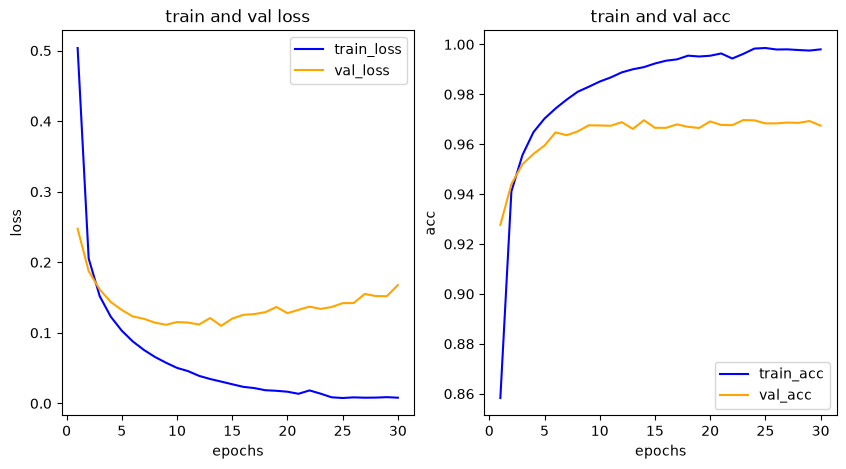

In [ ]:
#학습 결과 확인
import matplotlib.pyplot as plt
his_dict = history.history 
loss = his_dict['loss'] #학습데이터의 손실함수값
val_loss = his_dict['val_loss'] #검증데이터의 손실함수값
epochs = range(1, len(loss) + 1) # 1 ~ 30
fig = plt.figure(figsize = (10, 5))
ax1 = fig.add_subplot(1, 2, 1) #1행 2열 1번째 그래프
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()
#정확도 그래프 출력 
acc = his_dict['acc']  
val_acc = his_dict['val_acc'] 
ax2 = fig.add_subplot(1, 2, 2) 
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()
plt.show()

In [18]:
#모델 평가 : 테스트데이터로 모델 평가하기
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - acc: 0.9721 - loss: 0.1372


[0.13715986907482147, 0.972100019454956]

In [19]:
#예측하기
np.set_printoptions(precision=7) #소숫점이하 7자리까지 출력
result = model.predict(x_test)
print(result[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step
[8.3573834e-12 1.3387124e-14 1.0852464e-09 1.2783604e-04 3.1383645e-14
 4.8528626e-11 3.2572708e-17 9.9987197e-01 7.4332607e-10 1.0020315e-07]


In [ ]:
#np.argmax : result(예측값)의 모든 행에서 최대 인덱스값
arg_results = np.argmax(result, axis = -1)
arg_results[0]

np.int64(7)

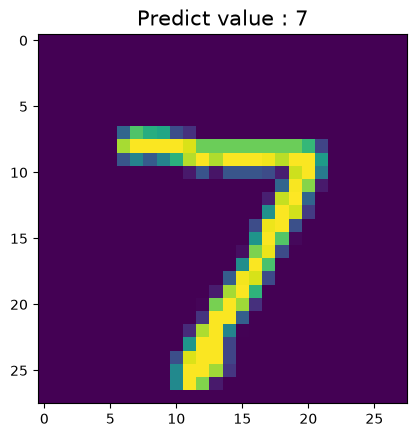

In [21]:
plt.imshow(x_test[0].reshape(28,28))
plt.title('Predict value : ' + str(arg_results[0]),fontsize=15)
plt.show()

7


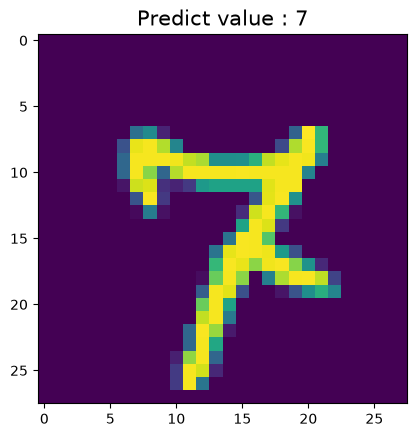

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [24]:
# 555번째의 이미지의 예측값을 출력. 이미지출력하기
print(arg_results[554])
plt.imshow(x_test[554].reshape(28,28))
plt.title('Predict value : ' + str(arg_results[554]),fontsize=15)
plt.show()

print(y_test[554])

In [25]:
#혼동행렬 출력하기
from sklearn.metrics import classification_report,confusion_matrix
cm = confusion_matrix(np.argmax(y_test,axis=-1), np.argmax(result,axis=-1))
cm

array([[ 966,    0,    2,    2,    2,    4,    2,    1,    1,    0],
       [   0, 1126,    4,    0,    0,    1,    1,    0,    3,    0],
       [   4,    4, 1007,    3,    3,    0,    3,    6,    2,    0],
       [   2,    0,    7,  985,    0,    3,    0,    3,    4,    6],
       [   0,    2,    7,    1,  947,    0,    7,    2,    2,   14],
       [   3,    0,    0,   17,    1,  851,    7,    1,    9,    3],
       [   8,    4,    2,    1,    1,    1,  939,    0,    2,    0],
       [   1,    8,   13,    3,    1,    0,    0,  994,    2,    6],
       [   5,    5,    7,    7,    0,    2,    3,    3,  940,    2],
       [   3,    7,    0,    6,   10,    3,    0,    8,    6,  966]])

In [ ]:
# 소프트맥스, 시그모이드 함수 구현하기
# np.exp : 지수함수
import numpy as np
def softmax(arr) :
    m = np.max(arr)
    arr = arr - m
    arr = np.exp(arr)
    return arr / np.sum(arr)

def sigmoid(x) :
    return 1 / (1+np.exp(-x))

case_1 = np.array([3.1,3.0,2.9])
case_2 = np.array([2.0,1.0,0.7])
np.set_printoptions(precision=3)
print("sigmoid:",sigmoid(case_1),",softmax:",softmax(case_1))
print("sigmoid:",sigmoid(case_2),",softmax:",softmax(case_2))

sigmoid: [0.957 0.953 0.948] ,softmax: [0.367 0.332 0.301]
sigmoid: [0.881 0.731 0.668] ,softmax: [0.61  0.224 0.166]


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
#http://bit.ly/33U6mH9 에서 이미지를 다운받아 cat.jpg 파일로 저장 
image_path = tf.keras.utils.get_file('cat.jpg', 'http://bit.ly/33U6mH9') 
print(image_path) 
image = plt.imread(image_path) # 이미지를 배열값 읽기
print(image.shape)
print(image[0])
titles = ['RGB Image', 'Red channel', 'Green channel', 'Blue channel']


/Users/apple/.keras/datasets/cat.jpg
(241, 320, 3)
[[223 220 203]
 [224 221 204]
 [224 221 204]
 [224 221 204]
 [224 221 204]
 [225 222 205]
 [225 222 205]
 [225 222 205]
 [224 221 204]
 [224 221 204]
 [224 221 204]
 [225 222 205]
 [225 222 205]
 [225 222 205]
 [225 222 205]
 [225 224 206]
 [226 225 207]
 [224 225 207]
 [226 225 207]
 [226 225 207]
 [226 225 207]
 [226 225 207]
 [226 225 207]
 [226 225 207]
 [226 223 206]
 [226 223 206]
 [226 223 206]
 [226 223 206]
 [228 222 206]
 [229 223 207]
 [229 223 207]
 [229 223 207]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [228 225 206]
 [230 223 204]
 [230 223 204]
 [231 224 205]
 [231 224 205]
 [232 225 206]
 [232 225 206]
 [231 224 205]
 [231 224 205]
 [231 224 205]
 [231 224 205]
 [231 224 205]
 [231 224 205]
 [232 225 206]
 [232 225 206]
 [232 225 206]
 [23

In [ ]:
from numpy import array, zeros_like
def channel(image, color):  #image, 0
    if color not in (0, 1, 2): return image
    c = image[..., color] #c : red영역
    
    #zeros_like(c) : c배열과 같은 형태의 배열. 요소의 값이 전부 0인 배열 
    z = zeros_like(c)
    print('배열크기',c.shape,z.shape)
    #transpose : 배열의 형태를 변경.
    return array([(c, z, z), (z, c, z), (z, z, c)][color]).transpose(1,2,0)


배열크기 (241, 320) (241, 320)
배열크기 (241, 320) (241, 320)
배열크기 (241, 320) (241, 320)


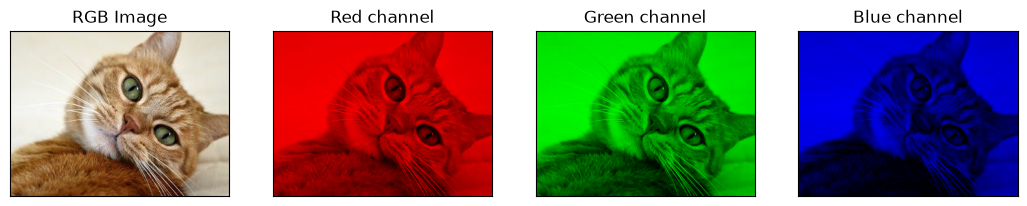

In [40]:
colors = range(-1, 3) # -1 ~ 2. -1,0,1,2
fig, axes = plt.subplots(1, 4, figsize=(13,3)) #1행4열짜리 그림판
#axes : 4 개의 그림판
#titles : ['RGB Image', 'Red channel', 'Green channel', 'Blue channel']
#colors : -1 ,0,1,2
#zip : [(axes[0],titles[0],colors[0]),(...),(,,,)]
objs = zip(axes, titles, colors)
for ax, title, color in objs:  #Red channel, 0
    # color : -1 => 원본이미지 출력
    ax.imshow(channel(image, color)) #이미지 출력 
    ax.set_title(title)
    ax.set_xticks(()) #x축의 내용 없앰
    ax.set_yticks(()) #y축의 내용 없앰
plt.show()